hypothesis yeh hai ke Genetically Modified (GM) seeds ek "Labor-Saving" technology hai. Matlab, jab kisan GM seeds istemal karta hai, toh usse mehnat (labor) kam karni padti hai lekin paidawar (productivity) aur munafa (GDP) badh jata hai.

### Glossary of Variables

| Variable Name                  | Simple Definition                                                                 | Original Source                          | Original Intention / Purpose |
|--------------------------------|-----------------------------------------------------------------------------------|------------------------------------------|------------------------------|
| **Year**                       | The year of observation (2005 to 2019)                                            | USDA & other official records            | To track changes over time |
| **State**                      | Name of the U.S. state (13 major corn-producing states)                           | USDA                                     | To identify each geographic unit |
| **Employment**                 | Number of people employed in agriculture                                          | Bureau of Labor Statistics (BLS)         | Control for labor input |
| **gm_corn_pct**                | Percentage of corn acres planted with GM seeds                                    | USDA ERS                                 | Raw GM adoption rate |
| **Actual GM Acres**            | Total acres planted with GM corn                                                  | Calculated                               | Convert percentage to absolute area |
| **Corn_Yield_BU_per_Acre**     | Average corn yield in bushels per acre                                            | USDA NASS                                | Control for productivity per acre |
| **Ag_GDP**                     | Total Agricultural GDP (in millions of dollars)                                   | USDA                                     | Measure of economic output |
| **Total Land Operated**        | Total agricultural land operated by farms                                         | USDA                                     | Denominator for normalization |
| **GM_intensity**               | Actual GM Acres ÷ Total Land Operated                                             | Calculated                               | **Main independent variable** - shows GM adoption intensity |
| **Labor_per_1000_acres**       | Agricultural workers per 1,000 acres                                              | Calculated                               | Control for labor intensity |
| **Export per acre**            | Agricultural export value per acre                                                | Calculated                               | Normalized export measure |
| **Ag_GDP_per_acre**            | Ag_GDP ÷ Total Land Operated                                                      | Calculated                               | **Main dependent variable** - productivity per acre |

In [14]:
# Step 1: Import necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Upload your Excel file
from google.colab import files
uploaded = files.upload()

# Step 3: Read the Excel file (change the filename if needed)
df = pd.read_excel('GMO_Master_Clean_13States.xlsx')   # ← Change this name to match your file

# Step 4: Basic information
print("Shape of dataset:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nFirst 5 rows:")
display(df.head())

# Step 5: Check for missing values
print("\nMissing values:")
print(df.isnull().sum())

Saving GMO_Master_Clean_13States.xlsx to GMO_Master_Clean_13States (2).xlsx
Shape of dataset: (195, 14)

Columns: ['Year', 'State', 'Employment', 'gm_corn_pct', 'Total_Acres_Planted', 'Actual GM Acres', 'Corn_Yield_BU_per_Acre', 'Ag_GDP', 'Labor_per_1000_acres', 'Export', 'Export per acre', 'Total Land Operated', 'GM_intensity', 'Ag_GDP_per_acre']

First 5 rows:


,Year,State,Employment,gm_corn_pct,Total_Acres_Planted,Actual GM Acres,Corn_Yield_BU_per_Acre,Ag_GDP,Labor_per_1000_acres,Export,Export per acre,Total Land Operated,GM_intensity,Ag_GDP_per_acre
0,2005,Illinois,2150.0,36,12100000,4356000.0,143,2509.200,0.079630,917.8405,0.000034,27000000,0.161333,0.000093
1,2005,Indiana,710.0,26,5900000,1534000.0,154,2179.050,0.047651,384.7189,0.000026,14900000,0.102953,0.000146
2,2005,Iowa,870.0,60,12800000,7680000.0,173,5004.575,0.027885,920.0162,0.000029,31200000,0.246154,0.000160
3,2005,Kansas,NaN,63,3650000,2299500.0,135,3254.950,0.000000,194.7635,0.000004,47160000,0.048760,0.000069
4,2005,Michigan,2220.0,40,2250000,900000.0,143,2258.100,0.219802,96.3087,0.000010,10100000,0.089109,0.000224



Missing values:
Year                      0
State                     0
Employment                7
gm_corn_pct               0
Total_Acres_Planted       0
Actual GM Acres           0
Corn_Yield_BU_per_Acre    0
Ag_GDP                    0
Labor_per_1000_acres      0
Export                    0
Export per acre           0
Total Land Operated       0
GM_intensity              0
Ag_GDP_per_acre           0
dtype: int64


Since we have seven missing values in Employment, To achieve Higher accuracy, we wll drop those seven rows. Hence, our dataset becomes slightly smaller (195 → ~188 rows).

In [15]:
# Before dropping
print("Before dropping - Shape:", df.shape)
print("Before - GM_intensity mean:", df['GM_intensity'].mean().round(4))
print("Before - Ag_GDP mean:", df['Ag_GDP'].mean().round(2))

# After dropping
df_clean = df.dropna(subset=['Employment']).copy()
print("\nAfter dropping - Shape:", df_clean.shape)
print("After - GM_intensity mean:", df_clean['GM_intensity'].mean().round(4))
print("After - Ag_GDP mean:", df_clean['Ag_GDP'].mean().round(2))

Before dropping - Shape: (195, 14)
Before - GM_intensity mean: 0.188
Before - Ag_GDP mean: 4917.81

After dropping - Shape: (188, 14)
After - GM_intensity mean: 0.1888
After - Ag_GDP mean: 4946.32


In [16]:
from IPython.display import display, Markdown

def report(text):
    display(Markdown(text))


text = """
# Missing Data Impact

Dropping 7 rows had almost zero impact on our overall distribution of our main variables.

This is good news because missing rows were not biasing our data at all. Since we have seven missing values in Employment, To achieve Higher accuracy, we dropped those seven rows. Hence, our dataset became slightly smaller (195 → ~188 rows).
"""

report(text)


# Missing Data Impact

Dropping 7 rows had almost zero impact on our overall distribution of our main variables.

This is good news because missing rows were not biasing our data at all. Since we have seven missing values in Employment, To achieve Higher accuracy, we dropped those seven rows. Hence, our dataset became slightly smaller (195 → ~188 rows).


In [17]:
# Step 6: Basic summary statistics for key variables
key_vars = ['GM_intensity', 'Ag_GDP', 'Ag_GDP_per_acre', 'Corn_Yield_BU_per_Acre',
            'Labor_per_1000_acres', 'Export per acre']

print("=== Summary Statistics ===")
print(df[key_vars].describe().round(4))     #df.describe is used as Outlier Detection tool!

# Step 7: Check correlation with our main variables
print("\n=== Correlation with Ag_GDP ===")
correlation = df[key_vars].corr()['Ag_GDP'].sort_values(ascending=False)
print(correlation.round(4))

print("\n=== Correlation with Ag_GDP_per_acre ===")
correlation_per_acre = df[key_vars].corr()['Ag_GDP_per_acre'].sort_values(ascending=False)
print(correlation_per_acre.round(4))

=== Summary Statistics ===
       GM_intensity      Ag_GDP  Ag_GDP_per_acre  Corn_Yield_BU_per_Acre  \
count      195.0000    195.0000         195.0000                195.0000   
mean         0.1880   4917.8077           0.0002                151.8359   
std          0.1176   2305.6296           0.0001                 25.1405   
min          0.0104   1457.4500           0.0000                 75.0000   
25%          0.0919   3188.2500           0.0001                135.0000   
50%          0.1816   4355.9500           0.0002                153.0000   
75%          0.2648   5897.3625           0.0003                171.0000   
max          0.4253  12910.0500           0.0005                210.0000   

       Labor_per_1000_acres  Export per acre  
count              195.0000         195.0000  
mean                 0.0536           0.0000  
std                  0.0569           0.0000  
min                  0.0000           0.0000  
25%                  0.0132           0.0000  
50%   

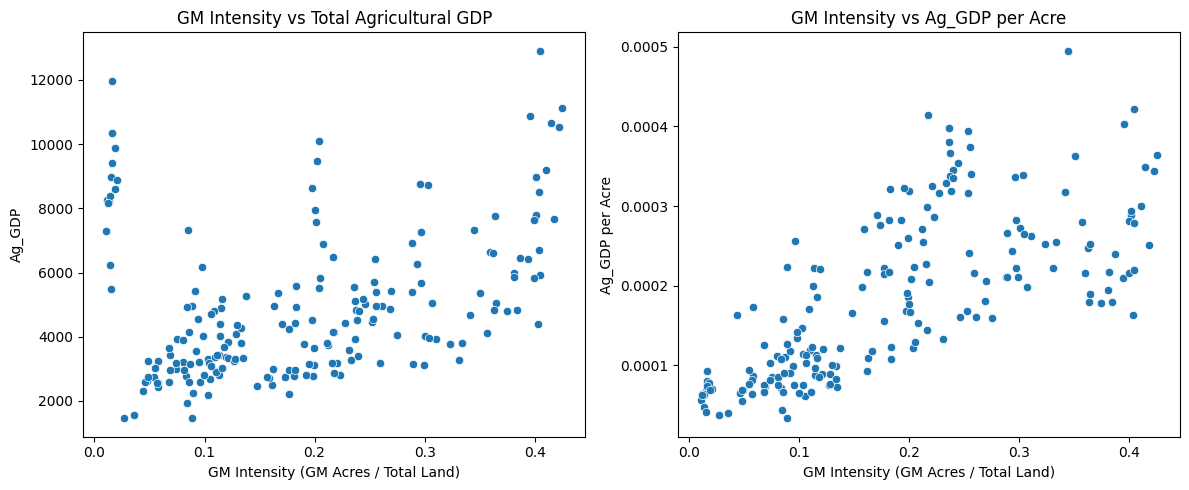

In [18]:
# Step 8: Scatter Plots

plt.figure(figsize=(12, 5))

# Plot 1: GM_intensity vs Ag_GDP (total)
plt.subplot(1, 2, 1)
sns.scatterplot(data=df, x='GM_intensity', y='Ag_GDP')
plt.title('GM Intensity vs Total Agricultural GDP')
plt.xlabel('GM Intensity (GM Acres / Total Land)')
plt.ylabel('Ag_GDP')

# Plot 2: GM_intensity vs Ag_GDP_per_acre
plt.subplot(1, 2, 2)
sns.scatterplot(data=df, x='GM_intensity', y='Ag_GDP_per_acre')
plt.title('GM Intensity vs Ag_GDP per Acre')
plt.xlabel('GM Intensity (GM Acres / Total Land)')
plt.ylabel('Ag_GDP per Acre')

plt.tight_layout()
plt.show()

In [19]:
# Install linearmodels (run only once)
!pip install linearmodels -q

from linearmodels.panel import PanelOLS
import statsmodels.api as sm

# Prepare data for panel regression
df_clean = df_clean.set_index(['State', 'Year'])

# Model 1: Using Ag_GDP_per_acre as dependent variable (recommended)
exog_vars = ['GM_intensity', 'Corn_Yield_BU_per_Acre', 'Labor_per_1000_acres', 'Export per acre']
exog = sm.add_constant(df_clean[exog_vars])

model1 = PanelOLS(df_clean['Ag_GDP_per_acre'], exog, entity_effects=True, time_effects=True) #applying fixed effects for state and year
results1 = model1.fit()

print("=== Model 1: Ag_GDP_per_acre as Dependent Variable ===")
print(results1)

=== Model 1: Ag_GDP_per_acre as Dependent Variable ===
                          PanelOLS Estimation Summary                           
Dep. Variable:        Ag_GDP_per_acre   R-squared:                        0.3238
Estimator:                   PanelOLS   R-squared (Between):              0.6656
No. Observations:                 188   R-squared (Within):               0.3446
Date:                Sat, Apr 04 2026   R-squared (Overall):              0.5781
Time:                        18:48:28   Log-likelihood                    1728.8
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      18.796
Entities:                          13   P-value                           0.0000
Avg Obs:                       14.462   Distribution:                   F(4,157)
Min Obs:                       12.000                                           
Max Obs:                       15.000   F-statistic (r

In [20]:
from IPython.display import display, Markdown

def report(text):
    display(Markdown(text))

text = """
# R-squared Types Interpretation

## 1. R-squared (Within) — 0.3446 (34.4%)
This number indicates the percentage of variation in dependent variable caused by independent variables over the time in each state.
If a state starts to use technology, how much variation is caused in its income due to increase in technology?

## 2. R-squared (Between) — 0.6656 (66.5%)
This number indicates how much of our chosen independent variables (GMO Intensity, Yield, etc.) successfully explain the structural and natural differences between states.

## 3. R-squared (Overall) — 0.5781 (57.8%)
This number indicates overall report card of the model. It is a weighted combination of both "Within" and "Between" effects, showing how well the model explains the total variation across the entire dataset (all states and all years combined).

## 4. R-squared (Model) — 0.3238
This number indicates how strong is the statistical formula of the model. It indicates how successfully model is able to find the pattern between the predictors and the response variable after adjusting for the mathematical structure of the regression confirming that our results are not just by chance but based on a solid mathematical structure.
"""

report(text)


# R-squared Types Interpretation

## 1. R-squared (Within) — 0.3446 (34.4%)
This number indicates the percentage of variation in dependent variable caused by independent variables over the time in each state.
If a state starts to use technology, how much variation is caused in its income due to increase in technology?

## 2. R-squared (Between) — 0.6656 (66.5%)
This number indicates how much of our chosen independent variables (GMO Intensity, Yield, etc.) successfully explain the structural and natural differences between states.

## 3. R-squared (Overall) — 0.5781 (57.8%)
This number indicates overall report card of the model. It is a weighted combination of both "Within" and "Between" effects, showing how well the model explains the total variation across the entire dataset (all states and all years combined).

## 4. R-squared (Model) — 0.3238
This number indicates how strong is the statistical formula of the model. It indicates how successfully model is able to find the pattern between the predictors and the response variable after adjusting for the mathematical structure of the regression confirming that our results are not just by chance but based on a solid mathematical structure.


In [21]:
from IPython.display import display, Markdown

def report(text):
    display(Markdown(text))

text = """
# R-squared

###R-squared shows the strength of our model.

Understand it this way: no model is perfect in this world. If any model gives an R-squared score of 100% or 1.00, it means that model is able to identify all the factors affecting the dependent variable.

Hence, 34% or 0.34 means the changes we see affecting our dependent variable are directly linked (or explained) by our independent variables. The other 66% or 0.66 is due to external factors.

## Dependent vs Independent Variables

Dependent variable is the one we are trying to investigate.

Independent variables are the ones that are causing affect on the dependent variable.

If R-squared becomes 100, that means there is none left as unknown cause behind the affect on dependent variable.
"""

report(text)


# R-squared

###R-squared shows the strength of our model.

Understand it this way: no model is perfect in this world. If any model gives an R-squared score of 100% or 1.00, it means that model is able to identify all the factors affecting the dependent variable.

Hence, 34% or 0.34 means the changes we see affecting our dependent variable are directly linked (or explained) by our independent variables. The other 66% or 0.66 is due to external factors.

## Dependent vs Independent Variables

Dependent variable is the one we are trying to investigate.

Independent variables are the ones that are causing affect on the dependent variable.

If R-squared becomes 100, that means there is none left as unknown cause behind the affect on dependent variable.


Dependent Variable (Y) → The thing we are trying to explain or predict.

Independent Variables (X) → The things we think influence or explain the dependent variable.

Dependent Variable (Y) :
**Ag_GDP_per_acre** is our dependent variable. In real life, it means (Agricultural GDP per acre) — how much economic value (in dollars) is generated from each acre of land in agriculture. it is the main outcome we are trying to understand.

Independent Variables (X):
These are the variables we use to explain changes in **Ag_GDP_per_acre**:


1. **GM_intensity** ← Main independent variable (the one we care about most)
2. **Corn_Yield_BU_per_Acre**
3. **Labor_per_1000_acres**
4. **Export per acre**
5. **const** (the constant / intercept — always included automatically)


In [22]:
from IPython.display import display, Markdown

def report(text):
    display(Markdown(text))

text = """
# Pipeline

## 1. Source raw data from government APIs.

## 2. Clean and merge mismatched datasets.
- Fingerprinting
- Time-Series Alignment
- Handling missing values
- Outlier Detection: Identifying anomalies in labor and yield data.

## 3. Normalize variables for scientific accuracy.
- Variable Transformation and denominator selection
- Statistical Modelling
    - Fixed effects : Erasing Omitted Variable Bias
    - P-Value & R-Squared

## 4. Analyze and visualize correlations using Python.
- Exploratory Data Analysis
- Visualization
    - Heat map construction
"""

report(text)


# Pipeline

## 1. Source raw data from government APIs.

## 2. Clean and merge mismatched datasets.
- Fingerprinting
- Time-Series Alignment
- Handling missing values
- Outlier Detection: Identifying anomalies in labor and yield data.

## 3. Normalize variables for scientific accuracy.
- Variable Transformation and denominator selection
- Statistical Modelling
    - Fixed effects : Erasing Omitted Variable Bias
    - P-Value & R-Squared

## 4. Analyze and visualize correlations using Python.
- Exploratory Data Analysis
- Visualization
    - Heat map construction


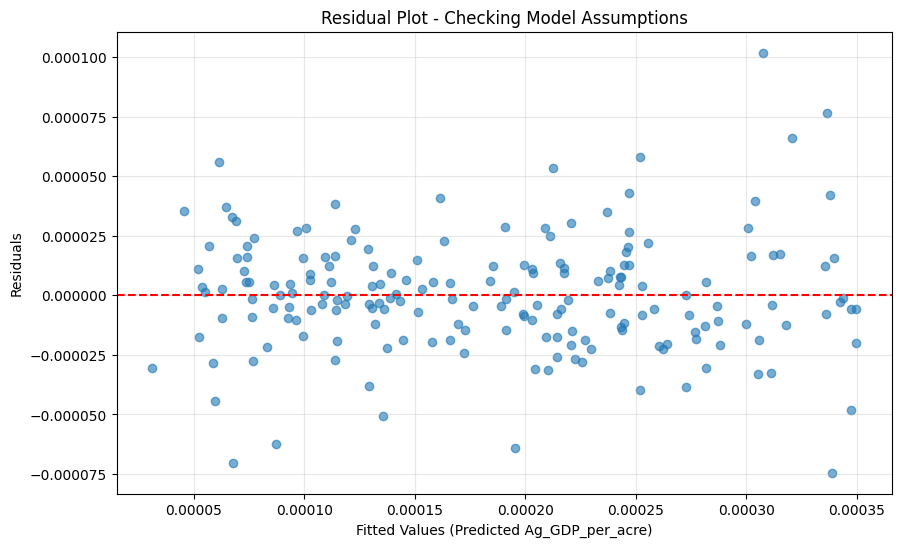

Mean of residuals: -0.0


In [23]:
# Get the fitted values and residuals from the model
fitted_values = results1.fitted_values
residuals = results1.resids

# Residual Plot
plt.figure(figsize=(10, 6))
plt.scatter(fitted_values, residuals, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Fitted Values (Predicted Ag_GDP_per_acre)')
plt.ylabel('Residuals')
plt.title('Residual Plot - Checking Model Assumptions')
plt.grid(True, alpha=0.3)
plt.show()

# Also print summary of residuals
print("Mean of residuals:", residuals.mean().round(6))

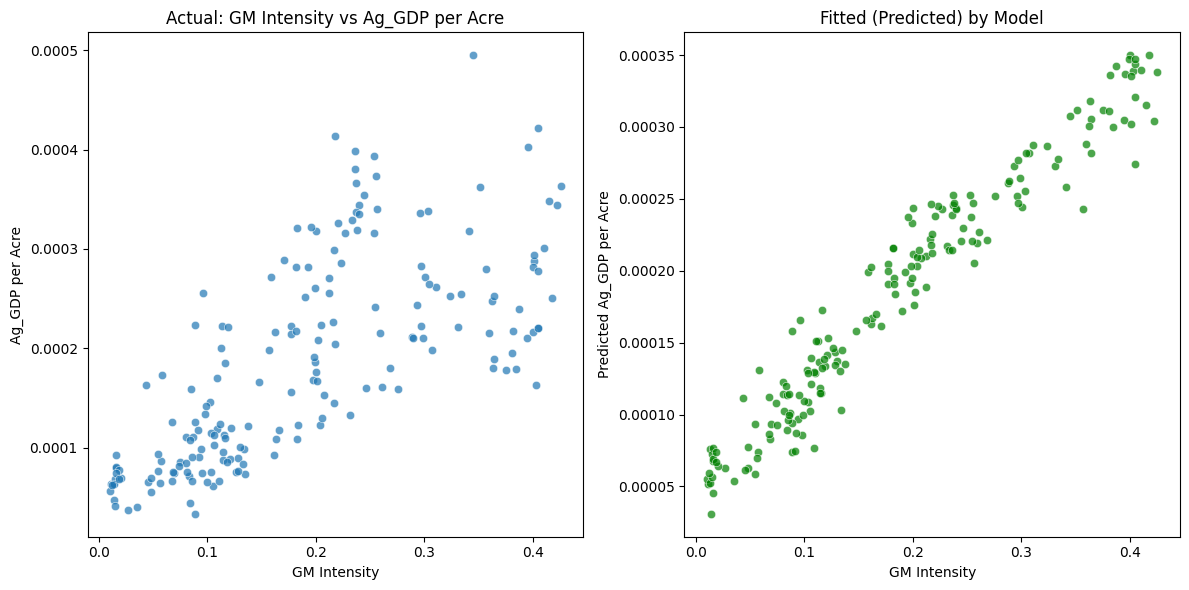

In [24]:
# Add fitted values to the dataframe for plotting
df_clean['Fitted_Ag_GDP_per_acre'] = fitted_values

plt.figure(figsize=(12, 6))

# Scatter: Actual data
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_clean.reset_index(), x='GM_intensity', y='Ag_GDP_per_acre', alpha=0.7)
plt.title('Actual: GM Intensity vs Ag_GDP per Acre')
plt.xlabel('GM Intensity')
plt.ylabel('Ag_GDP per Acre')

# Scatter: Fitted values (after model)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_clean.reset_index(), x='GM_intensity', y='Fitted_Ag_GDP_per_acre', alpha=0.7, color='green')
plt.title('Fitted (Predicted) by Model')
plt.xlabel('GM Intensity')
plt.ylabel('Predicted Ag_GDP per Acre')

plt.tight_layout()
plt.show()

In [25]:
from IPython.display import display, Markdown

def report(text):
    display(Markdown(text))

text = """
# Results & Interpretation

We ran a **Panel Regression with Fixed Effects** (State and Year fixed effects) to test the hypothesis.

## Model 1: Dependent Variable = Ag_GDP_per_acre

**Key Result:**

- **GM_intensity** coefficient = **0.0006**
- **P-value** = **0.0000** (highly statistically significant)

**Interpretation:**

When a state increases its GM corn intensity by 0.1 (i.e., 10 percentage points more of its total agricultural land is planted with GM corn), **agricultural GDP per acre increases by 0.00006**, on average, after controlling for:
- Corn yield per acre
- Labor intensity (workers per 1,000 acres)
- Export value per acre
- State-specific constant factors (soil, climate, policies, etc.)
- Year-specific shocks (national weather, prices, policies, etc.)

This provides **strong statistical support** for the hypothesis that higher GM corn adoption is positively associated with higher agricultural productivity per acre.

## Model Fit:
- R-squared (Within) = 0.3446 → The model explains about 34.5% of the variation **within states** over time.
- The residual plot shows reasonably random scatter around zero, suggesting the model assumptions are mostly satisfied.

## Comparison with Simple Correlation

- Simple correlation between GM_intensity and Ag_GDP_per_acre was **0.7195** (very strong).
- After adding controls and fixed effects, the effect becomes smaller but remains **highly significant**.

This is expected and positive: the fixed effects model removes many confounding factors, giving us a **more reliable and trustworthy** estimate of the true relationship.

## Conclusion from Economic Analysis:

The data supports the hypothesis. Higher adoption of GM corn technology is associated with improved agricultural economic output per acre, even after accounting for other important macroeconomic factors and fixed effects.
"""

report(text)


# Results & Interpretation

We ran a **Panel Regression with Fixed Effects** (State and Year fixed effects) to test the hypothesis.

## Model 1: Dependent Variable = Ag_GDP_per_acre

**Key Result:**

- **GM_intensity** coefficient = **0.0006**  
- **P-value** = **0.0000** (highly statistically significant)

**Interpretation:**

When a state increases its GM corn intensity by 0.1 (i.e., 10 percentage points more of its total agricultural land is planted with GM corn), **agricultural GDP per acre increases by 0.00006**, on average, after controlling for:
- Corn yield per acre
- Labor intensity (workers per 1,000 acres)
- Export value per acre
- State-specific constant factors (soil, climate, policies, etc.)
- Year-specific shocks (national weather, prices, policies, etc.)

This provides **strong statistical support** for the hypothesis that higher GM corn adoption is positively associated with higher agricultural productivity per acre.

## Model Fit:
- R-squared (Within) = 0.3446 → The model explains about 34.5% of the variation **within states** over time.
- The residual plot shows reasonably random scatter around zero, suggesting the model assumptions are mostly satisfied.

## Comparison with Simple Correlation

- Simple correlation between GM_intensity and Ag_GDP_per_acre was **0.7195** (very strong).
- After adding controls and fixed effects, the effect becomes smaller but remains **highly significant**.

This is expected and positive: the fixed effects model removes many confounding factors, giving us a **more reliable and trustworthy** estimate of the true relationship.

## Conclusion from Economic Analysis:

The data supports the hypothesis. Higher adoption of GM corn technology is associated with improved agricultural economic output per acre, even after accounting for other important macroeconomic factors and fixed effects.


In [26]:
# Model 2: Using total Ag_GDP as dependent variable (for comparison)
model2 = PanelOLS(df_clean['Ag_GDP'], exog, entity_effects=True, time_effects=True)
results2 = model2.fit()

print("=== Model 2: Total Ag_GDP as Dependent Variable ===")
print(results2)

=== Model 2: Total Ag_GDP as Dependent Variable ===
                          PanelOLS Estimation Summary                           
Dep. Variable:                 Ag_GDP   R-squared:                        0.0993
Estimator:                   PanelOLS   R-squared (Between):             -0.1754
No. Observations:                 188   R-squared (Within):               0.0707
Date:                Sat, Apr 04 2026   R-squared (Overall):             -0.0948
Time:                        18:48:29   Log-likelihood                   -1514.0
Cov. Estimator:            Unadjusted                                           
                                        F-statistic:                      4.3266
Entities:                          13   P-value                           0.0024
Avg Obs:                       14.462   Distribution:                   F(4,157)
Min Obs:                       12.000                                           
Max Obs:                       15.000   F-statistic (robu

In [27]:
from IPython.display import display, Markdown

def report(text):
    display(Markdown(text))

text = """
# Model Comparison

We ran two panel regressions with fixed effects:

**Model 1 (Ag_GDP_per_acre as dependent variable)**
GM_intensity coefficient = 0.0006, p-value = 0.0000
→ Strong and highly significant positive effect.

**Model 2 (Total Ag_GDP as dependent variable)**
GM_intensity coefficient ≈ 0 (not significant)
→ No clear effect.

**Conclusion:**
The positive impact of GM corn adoption becomes clearly visible only when we measure **productivity per acre** rather than total GDP. This confirms that normalization is essential. Higher GM_intensity is associated with improved agricultural productivity per acre, supporting the original hypothesis.
"""

report(text)


# Model Comparison

We ran two panel regressions with fixed effects:

**Model 1 (Ag_GDP_per_acre as dependent variable)**  
GM_intensity coefficient = 0.0006, p-value = 0.0000  
→ Strong and highly significant positive effect.

**Model 2 (Total Ag_GDP as dependent variable)**  
GM_intensity coefficient ≈ 0 (not significant)  
→ No clear effect.

**Conclusion:**  
The positive impact of GM corn adoption becomes clearly visible only when we measure **productivity per acre** rather than total GDP. This confirms that normalization is essential. Higher GM_intensity is associated with improved agricultural productivity per acre, supporting the original hypothesis.
